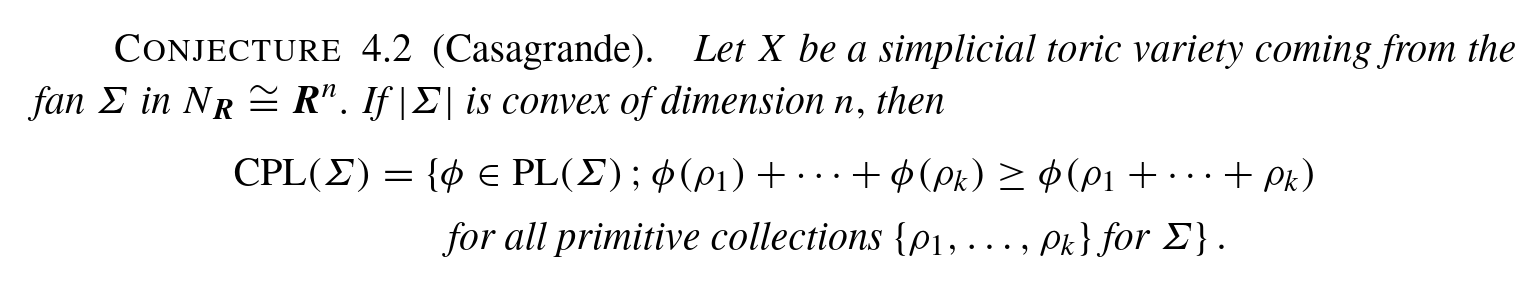

In [2]:
import SimplicialComplex as sc
import json
import sympy as sp
import numpy as np
from IPython.display import display
from itertools import combinations,permutations

def read_file(filename):
    with open(filename, 'rb') as f:
        data = f.readlines()
        data = [x.strip() for x in data]
    return data

def load_seeds(n,m):
    db_path = 'final_results/CSPLS_%d_%d' % (n, m)
    list_facets = [json.loads(facets_bytes) for facets_bytes in read_file(db_path)]
    return [sc.PureSimplicialComplex(facets_set) for facets_set in list_facets]

### Function for testing primitive collections

In [110]:
from sage.all import *

def enumerate_inequalities(K:sc.SimplicialComplex,char_map):
    m=K.m
    n=K.n
    K.compute_MNF_set()
    K.MNF_bin_to_MNF()
    facets_list = [np.array(sc.binary_to_face_0(facet_bin,m)) for facet_bin in K.facets_bin]
    N = len(facets_list)
    inequality_matrix = np.zeros((len(K.MNF_set),m))
    for l in range(len(K.MNF_set)):
        sigma = K.MNF_set[l]
        vec_char_sigma = np.zeros((m,1))
        vec_char_sigma[[i-1 for i in sigma],:] = 1
        x = np.dot(char_map,vec_char_sigma)
        for k in range(0,N): # Trouver dans quel cone il est
            y = np.dot(np.linalg.inv(char_map[:,facets_list[k]]),x)
            if np.all(y>=0):
                inequality_matrix[l,:] = vec_char_sigma.T.copy()
                for j in range(n):
                    if y[j][0]!=0:
                        inequality_matrix[l][facets_list[k][j]] = -y[j][0]
                break
    # display(inequality_matrix)
    return inequality_matrix


def find_convex(K,char_map):
    (m,n) = (K.m,K.n)
    A = matrix(ZZ, n, m, lambda i, j: 1 if i == j else 0)
    b = vector(ZZ, [0] * n)

    # Create the polyhedron using the equality constraints
    M=enumerate_inequalities(K,char_map)
    B = np.zeros((M.shape[0],M.shape[1]+1))
    B[:,1:m+1] = M
    list_of_lists_B = B.tolist()
    # Q = Cone([r for r in Polyhedron(ieqs=[vector(ZZ, row) for row in list_of_lists_B],eqns=[(b[i],) + tuple(A.row(i)) for i in range(n)]).Vrepresentation])
    C = Cone([r for r in (Polyhedron(ieqs=[vector(ZZ, row) for row in list_of_lists_B],eqns=[(b[i],) + tuple(A.row(i)) for i in range(n)])).Vrepresentation()])
    # h=200*Q.Hilbert_basis()[0] + 111*Q.Hilbert_basis()[1]
    # h_np=np.array(h)
    print(len(C.Hilbert_basis()))
    for h in C.Hilbert_basis():
        h_np=np.array(h)
        # print(np.dot(M,h_np.T))
        list_V = []
        facets_list = [np.array(sc.binary_to_face_0(facet_bin,m)) for facet_bin in K.facets_bin]
        for facet in facets_list:
            # list_V.append(vector(ZZ,x_int[:n]))
            v = np.linalg.solve(char_map[:,facet].T,-h_np[facet])
            v_int = np.array([int(v_i) for v_i in v])
            if (np.dot(char_map[:,facet].T,v_int) == -h_np[facet]).all():
                list_V.append(vector(ZZ,list(v_int)))
            else: print(np.dot(char_map[:,facet].T,v_int) +h_np[facet])

        # print(list_V)
        for i in range(len(facets_list)):
            facet_1 = facets_list[i]
            facet_1_np = np.zeros(m)
            facet_1_np[facet_1] = 1
            for j in range(i+1,len(facets_list)):
                facet_2 = facets_list[j]
                facet_2_np = np.zeros(m)
                facet_2_np[facet_2] = 1
                ridge_np = np.multiply(facet_1_np,facet_2_np)
                if np.count_nonzero(ridge_np)==n-1:
                    if np.any(np.dot(char_map[:,np.where(ridge_np==1)[0]].T,list_V[j]-list_V[i])!=0):
                        print("not well-defined")
                        continue
                    v1 = np.where(facet_2_np-ridge_np)[0]
                    v2 = np.where(facet_1_np-ridge_np)[0]
                    w = char_map[:,v2] - char_map[:,v1]
                    if np.dot(list_V[j]-list_V[i],w)<0:
                        print("non convex",np.dot(list_V[j]-list_V[i],w),h)


        # R = Polyhedron(vertices=list_V)
        # if dimension(R)==n:
        #     print(NormalFan(R).rays())
        # S = Polyhedron(ieqs=[(h[i],) + tuple(list(char_map[:,i].T)) for i in range(m)])

        # if dimension(S)==n:
        #     print(NormalFan(S).rays())
        #     print(len(S.Vrepresentation()),len(K.facets))
        



n=8
m= n+4
K_7_58 = sc.PureSimplicialComplex(None,[[3,4,11],[3,4,12],[1,4,5,9],[1,4,5,12],[1,4,9,11],[2,5,8,12],[3,6,10,11],[3,8,10,12],[1,2,5,7,9],[1,6,7,9,11],[2,6,7,8,10],[6,7,9,10,11]],8)
char_map_1 = np.zeros((n,m))
char_map_1[:,:n]=np.eye(n)
char_map_1[:,n:] = np.array([[-1,0,0,-1],[-2,-1,2,-1],[1,0,-1,0],[1,1,-1,0],[-1,0,1,-1],[-1,-1,0,-1],[-2,-1,1,-1],[-1,-1,1,-1]])
find_convex(K_7_58,char_map_1)

n=4
m= n+4
K_3_11 = sc.PureSimplicialComplex(None,[[2,6], [2,8], [1,2,5], [1,4,5], [1,4,8], [1,5,7], [3,4,7], [3,4,8], [3,6,7], [3,6,8], [5,6,7]],4)
char_map_2 = np.zeros((n,m))
char_map_2[:,:n]=np.eye(n)
char_map_2[:,n:] = np.array([[-1,1,0,0],[0,-1,2,1],[0,0,-1,-1],[-1,1,-1,-1]])
find_convex(K_3_11,char_map_2)

n=3
m=n+4
K_2_2 = sc.PureSimplicialComplex(None,[[1,4], [1,7], [2,5], [2,7], [3,6], [3,7], [4,5,6]],3)
char_map_3 = np.zeros((n,m))
char_map_3[:,:n]=np.eye(n)
char_map_3[:,n:] = np.array([[-1,0,-1,-1],[-1,-1,0,-1],[0,-1,-1,-1]])
find_convex(K_2_2,char_map_3) 

n=4
m=n+4
K_3_8 = sc.PureSimplicialComplex(None, [[2,6], [2,8], [3,7], [1,4,5], [1,4,8], [1,5,6], [3,4,8], [5,6,7]],4)
char_map_4 = np.zeros((n,m))
char_map_4[:,:n]=np.eye(n)
char_map_4[:,n:] = np.array([[-1,-1,0,-1],[0,-1,-1,-1],[-1,0,-1,-1],[-1,0,0,-1]])
find_convex(K_3_8,char_map_4) 

n=7
m=n+4
K_6_57 = sc.PureSimplicialComplex(None,[
    [2, 6, 9],
    [6, 8, 11],
    [7, 8, 11],
    [1, 2, 5, 10],
    [1, 2, 6, 8],
    [1, 2, 8, 10],
    [1, 7, 8, 10],
    [3, 4, 5, 9],
    [3, 4, 7, 11],
    [4, 6, 9, 11],
    [1, 3, 5, 7, 10],
    [3, 4, 5, 7, 10]
],7)
char_map_5 = np.zeros((n,m))
char_map_5[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_5[:,n:] = np.array([
    [-1, -1, -1, 0],
    [-1, -1, 0, 1],
    [0, -1, -1, -1],
    [1, 0, 0, -1],
    [0, -1, -1, 0],
    [-1, -1, 0, 0],
    [0, 0, -1, -1]
])
find_convex(K_6_57,char_map_5) 

K_6_56 = sc.PureSimplicialComplex(None,[
    [2, 5, 11],
    [3, 4, 10],
    [3, 4, 11],
    [3, 9, 11],
    [1, 4, 5, 8],
    [1, 4, 5, 11],
    [1, 4, 8, 10],
    [2, 6, 7, 9],
    [3, 6, 9, 10],
    [1, 2, 5, 7, 8],
    [1, 6, 7, 8, 10],
    [6, 7, 8, 9, 10]
],7)
char_map_6 = np.zeros((n,m))
char_map_6[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_6[:,n:] = np.array([
    [-1, 0, 0, -1],
    [-2, -1, 2, -1],
    [1, 0, -1, 0],
    [1, 1, -1, 0],
    [-1, 0, 1, -1],
    [-1, -1, 0, -1],
    [-2, -1, 1, -1]
])
find_convex(K_6_56,char_map_6) 

K_6_55 = sc.PureSimplicialComplex(None,[
    [3, 4, 11],
    [3, 5, 10],
    [3, 9, 11],
    [4, 8, 11],
    [7, 9, 11],
    [1, 2, 7, 9],
    [1, 3, 5, 9],
    [4, 6, 8, 10],
    [1, 2, 5, 6, 10],
    [1, 2, 6, 7, 8],
    [2, 4, 6, 7, 8]
],7)
char_map_7 = np.zeros((n,m))
char_map_7[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_7[:,n:] = np.array([
    [0, -1, 0, 1],
    [-1, -2, -1, 0],
    [0, -1, -1, -1],
    [-1, -1, -1, -1],
    [0, -1, -1, 0],
    [-1,-1,-1,0],
    [-1, -1, 0, 0]
])
find_convex(K_6_55,char_map_7) 

K_6_54 = sc.PureSimplicialComplex(None,[
    [1, 2, 9],
    [1, 2, 10],
    [2, 5, 8],
    [2, 8, 10],
    [1, 3, 4, 10],
    [1, 3, 7, 9],
    [3, 4, 6, 10],
    [4, 6, 8, 10],
    [5, 6, 8, 11],
    [5, 7, 9, 11],
    [3, 4, 6, 7, 11]
],7)
char_map_8 = np.zeros((n,m))
char_map_8[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_8[:,n:] = np.array([
    [1, -1, -1, 0],
    [-1, 0, 1, 1],
    [2, -1, -2, -1],
    [1, -1, -2, -1],
    [-1, 0, 1, 0],
    [0, 0, -1, -1],
    [1, -1, -1, -1]
])
find_convex(K_6_54,char_map_8) 

2
4
2
2
2
2
2
2


In [109]:
K_6_53 = sc.PureSimplicialComplex(None,[
    [2, 6, 9],
    [2, 7, 9],
    [3, 6, 9],
    [3, 9, 11],
    [7, 9, 11],
    [1, 2, 6, 10],
    [1, 2, 7, 8],
    [3, 4, 5, 11],
    [3, 5, 6, 10],
    [4, 7, 8, 11],
    [1, 4, 5, 8, 10]
],7)
char_map_8_prime = np.zeros((n,m),dtype=int)
char_map_8_prime[:,:n]=np.eye(n,dtype=int)
for k_0 in range(-1,2):
    for k_1 in range(-1,2):
        for k_2 in range(-1,2):
# Convert the list of lists to a NumPy array
            char_map_8_prime[:,n:] = np.array([
                [-1, -1, -1, k_0],
                [-1, -2, -1, k_1],
                [1, 1, 0, -1],
                [0, 1, 0, -1],
                [1, 2, 0, -1],
                [0, -1, -1, k_2],
                [-1, -1, 0, 0]
            ],dtype=int)
            find_convex(K_6_53,char_map_8_prime)

4
[0 0 0 0 1 1 0]
[0 0 0 0 1 0 0]
[0 0 0 1 1 0 0]
[0 0 0 1 1 0 0]
[0 0 0 1 1 0 0]
not well-defined
not well-defined
not well-defined
not well-defined
not well-defined
not well-defined
not well-defined
not well-defined
not well-defined
not well-defined
not well-defined


IndexError: list index out of range

In [111]:
K_6_52 = sc.PureSimplicialComplex(None,[
    [1, 2, 10],
    [2, 8, 10],
    [1, 2, 7, 9],
    [1, 3, 4, 9],
    [1, 3, 4, 10],
    [1, 3, 7, 9],
    [2, 5, 7, 8],
    [3, 4, 6, 10],
    [3, 4, 6, 11],
    [4, 6, 8, 10],
    [5, 6, 8, 11],
    [5, 7, 9, 11]
],7)
char_map_9 = np.zeros((n,m))
char_map_9[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_9[:,n:] = np.array([
    [1, -1, -1, 0],
    [-1, 0, 1, 1],
    [2, -1, -2, -1],
    [1, -1, -2, -1],
    [-1, 0, 1, 0],
    [0, 0, -1, -1],
    [-1, 0, 2, 1]
])
find_convex(K_6_52,char_map_9) 

2


In [112]:
K_6_51 = sc.PureSimplicialComplex(None,[
    [8, 11],
    [1, 2, 8],
    [2, 6, 9],
    [4, 9, 11],
    [1, 7, 8, 10],
    [3, 4, 7, 11],
    [1, 2, 5, 6, 10],
    [1, 3, 5, 7, 10],
    [3, 4, 5, 6, 9],
    [3, 4, 5, 7, 10]
],7)
char_map_10 = np.zeros((n,m))
char_map_10[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_10[:,n:] = np.array([
    [-1, -1, -1, 0],
    [-1, -1, 0, 1],
    [0, -1, -1, -1],
    [1, 0, 0, -1],
    [0, -1, -1, 0],
    [0, -1, 0, 1],
    [0, 0, -1, -1]
])
find_convex(K_6_51,char_map_10) 

4


In [113]:
K_6_50=sc.PureSimplicialComplex(None,
[
    [9, 11],
    [1, 2, 9],
    [4, 8, 11],
    [1, 2, 6, 8],
    [1, 3, 5, 9],
    [2, 4, 6, 8],
    [3, 4, 7, 11],
    [3, 5, 7, 10],
    [1, 2, 5, 6, 10],
    [4, 6, 7, 8, 10]
],7)
char_map_11 = np.zeros((n,m))
char_map_11[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_11[:,n:] = np.array([
    [-1, -1, 0, 1],
    [-1, 0, 1, 2],
    [0, -1, -1, -1],
    [0, 1, 0, -1],
    [0, -1, -1, 0],
    [-1, 0, 0, 1],
    [0, 0, -1, -1]
])
find_convex(K_6_50,char_map_11) 

4


In [114]:
K_6_49=sc.PureSimplicialComplex(None,[
    [3, 4, 10],
    [3, 4, 11],
    [3, 9, 10],
    [1, 4, 6, 8],
    [1, 4, 6, 11],
    [1, 4, 8, 10],
    [1, 7, 8, 10],
    [2, 5, 6, 11],
    [2, 5, 7, 9],
    [3, 5, 9, 11],
    [7, 8, 9, 10],
    [1, 2, 6, 7, 8]
],7)
char_map_12 = np.zeros((n,m))
char_map_12[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_12[:,n:] = np.array([[-1,1,0,0],[0,-1,2,1],[0,0,-1,-1],[-1,1,-1,-1],[0,-1,1,0],[-1,0,1,0],[0,-1,1,1]])
find_convex(K_6_49,char_map_12) 

4


In [129]:
n=6
m=10
K_5_48=sc.PureSimplicialComplex(None,[
    [2, 8],
    [7, 10],
    [1, 2, 7],
    [4, 8, 10],
    [1, 2, 5, 9],
    [1, 6, 7, 9],
    [3, 4, 5, 8],
    [3, 4, 6, 10],
    [1, 3, 5, 6, 9],
    [3, 4, 5, 6, 9]
],6)
char_map_13 = np.zeros((n,m))
char_map_13[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_13[:,n:] = np.array([
    [-1, -1, -1, 0],
    [-1, -1, 0, 1],
    [0, -1, -1, -1],
    [1, 0, 0, -1],
    [0, -1, -1, 0],
    [0, 0, -1, -1]
])
find_convex(K_5_48,char_map_13) 

4


In [116]:
K_5_47=sc.PureSimplicialComplex(None,[
    [2, 5, 7],
    [3, 6, 10],
    [3, 8, 10],
    [5, 8, 10],
    [6, 7, 9],
    [1, 2, 4, 8],
    [1, 2, 4, 9],
    [1, 2, 5, 8],
    [1, 3, 4, 8],
    [1, 3, 4, 9],
    [3, 4, 6, 9],
    [5, 6, 7, 10]
],6)
char_map_14 = np.zeros((n,m))
char_map_14[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_14[:,n:] = np.array([
    [0, -1, -1, 0],
    [-1, -1, 0, 1],
    [1, 0, -1, -1],
    [1, 0, -1, 0],
    [-1, -1, 0, 0],
    [0, 1, 0, -1]
])
find_convex(K_5_47,char_map_14) 


4


In [117]:
K_5_46=sc.PureSimplicialComplex(None,[
    [1, 2, 7],
    [1, 4, 7],
    [1, 4, 10],
    [2, 5, 10],
    [3, 4, 9],
    [3, 4, 10],
    [1, 6, 7, 9],
    [2, 5, 6, 8],
    [3, 5, 8, 10],
    [3, 6, 8, 9],
    [6, 7, 8, 9]
],6)
char_map_15 = np.zeros((n,m))
char_map_15[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_15[:,n:] = np.array([
    [-1, 0, 0, -1],
    [-2, -1, 2, -1],
    [1, 0, -1, 0],
    [1, 1, -1, 0],
    [-1, -1, 1, -1],
    [-1, -1, 0, -1]
])
find_convex(K_5_46,char_map_15) 

2


In [118]:
K_5_45=sc.PureSimplicialComplex(None,[
    [1, 7, 9],
    [2, 5, 8],
    [2, 6, 8],
    [3, 4, 10],
    [6, 7, 10],
    [1, 2, 5, 9],
    [1, 2, 6, 7],
    [1, 3, 5, 9],
    [3, 4, 5, 8],
    [3, 4, 5, 9],
    [4, 6, 8, 10]
],6)
char_map_16 = np.zeros((n,m))
char_map_16[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_16[:,n:] = np.array([
    [-1, -1, -1, 0],
    [-1, -1, 0, 1],
    [0, -1, -1, -1],
    [1, 0, 0, -1],
    [0, -1, -1, 0],
    [-1, -1, 0, 0]
])
find_convex(K_5_45,char_map_16) 

4


In [119]:
K_5_44=sc.PureSimplicialComplex(None,[
    [2, 5, 10],
    [2, 6, 8],
    [3, 4, 9],
    [3, 4, 10],
    [3, 8, 9],
    [3, 8, 10],
    [1, 4, 5, 7],
    [1, 4, 5, 10],
    [1, 4, 7, 9],
    [1, 6, 7, 9],
    [6, 7, 8, 9],
    [1, 2, 5, 6, 7]
],6)
char_map_17 = np.zeros((n,m))
char_map_17[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_17[:,n:] = np.array([
    [-1, 1, 0, 0],
    [0, -1, 2, 1],
    [0, 0, -1, -1],
    [-1, 1, -1, -1],
    [-1, 0, 1, 0],
    [0, -1, 1, 1]
])
find_convex(K_5_44,char_map_17) 

4


In [120]:
K_5_43=sc.PureSimplicialComplex(None,
    [
    [2, 8],
    [1, 7, 9],
    [3, 4, 9],
    [3, 8, 9],
    [3, 8, 10],
    [7, 8, 9],
    [1, 2, 5, 7],
    [2, 5, 6, 10],
    [3, 4, 6, 10],
    [1, 4, 5, 6, 7],
    [1, 4, 5, 6, 10]
],6)
char_map_18 = np.zeros((n,m))
char_map_18[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_18[:,n:] = np.array([
    [-1, 1, 0, 0],
    [0, -1, 2, 1],
    [0, 0, -1, -1],
    [-1, 1, -1, -1],
    [-1, 0, 1, 0],
    [-1, 0, 0, -1]
])
find_convex(K_5_43,char_map_18) 

2


In [121]:
K_5_42=sc.PureSimplicialComplex(None,[
    [2, 8],
    [1, 2, 7],
    [4, 8, 10],
    [6, 7, 10],
    [1, 2, 5, 9],
    [1, 3, 5, 9],
    [1, 6, 7, 9],
    [3, 4, 5, 8],
    [3, 4, 5, 9],
    [3, 4, 6, 10]
],6)
char_map_19 = np.zeros((n,m))
char_map_19[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_19[:,n:] = np.array([
    [-1, -1, -1, 0],
    [-1, -1, 0, 1],
    [0, -1, -1, -1],
    [1, 0, 0, -1],
    [0, -1, -1, 0],
    [0, 1, 0, -1]
])
find_convex(K_5_42,char_map_19) 

4


In [122]:
K_5_41=sc.PureSimplicialComplex(None,[
    [1, 2, 8],
    [1, 2, 9],
    [1, 3, 8],
    [2, 5, 7],
    [2, 7, 9],
    [5, 8, 10],
    [1, 3, 4, 9],
    [3, 4, 6, 9],
    [3, 4, 6, 10],
    [4, 6, 7, 9],
    [5, 6, 7, 10]
],6)
char_map_20 = np.zeros((n,m))
char_map_20[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_20[:,n:] = np.array([
    [1, -1, -1, 0],
    [-1, 0, 1, 1],
    [2, -1, -2, -1],
    [1, -1, -2, -1],
    [-1, 0, 1, 0],
    [0, 0, -1, -1]
])
find_convex(K_5_41,char_map_20) 

char_map_21= np.zeros((n,m))
char_map_21[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_21[:,n:] = np.array([
    [0, -1, -1, 0],
    [-1, -1, 0, 1],
    [1, 0, -1, -1],
    [0, 0, -1, -1],
    [-1, -1, 0, 0],
    [0, 1, 0, -1]
])
find_convex(K_5_41,char_map_21) 

2
2


In [123]:
K_5_40=sc.PureSimplicialComplex(None,[
    [7, 10],
    [1, 7, 9],
    [2, 6, 8],
    [3, 4, 10],
    [1, 2, 5, 9],
    [1, 2, 6, 7],
    [1, 3, 5, 9],
    [3, 4, 5, 8],
    [3, 4, 5, 9],
    [4, 6, 8, 10]
],6)
char_map_22 = np.zeros((n,m))
char_map_22[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_22[:,n:] = np.array([
    [-1, -1, -1, 0],
    [-1, -1, 0, 1],
    [0, -1, -1, -1],
    [1, 0, 0, -1],
    [0, -1, -1, 0],
    [-1, -1, 0, 0]
])
find_convex(K_5_40,char_map_22) 

4


In [124]:
K_5_39=sc.PureSimplicialComplex(None,[
    [2, 5, 10],
    [2, 6, 8],
    [3, 4, 9],
    [3, 4, 10],
    [3, 8, 10],
    [1, 2, 5, 7],
    [1, 4, 5, 7],
    [1, 4, 5, 10],
    [1, 4, 7, 9],
    [1, 6, 7, 9],
    [3, 6, 8, 9],
    [6, 7, 8, 9]
],6)
char_map_23 = np.zeros((n,m))
char_map_23[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_23[:,n:] = np.array([
    [-1, 0, 0, -1],
    [-2, -1, 2, -1],
    [1, 0, -1, 0],
    [1, 1, -1, 0],
    [-1, 0, 1, -1],
    [-1, -1, 0, -1]
])
find_convex(K_5_39,char_map_23) 

2


In [131]:
K_5_38=sc.PureSimplicialComplex(None,[
    [7, 10],
    [1, 2, 7],
    [1, 7, 9],
    [2, 6, 8],
    [3, 4, 10],
    [4, 8, 10],
    [1, 3, 5, 9],
    [3, 4, 5, 9],
    [1, 2, 5, 6, 9],
    [3, 4, 5, 6, 8]
],6)
char_map_24 = np.zeros((n,m))
char_map_24[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_24[:,n:] = np.array([
    [-1, -1, -1, 0],
    [-1, -1, 0, 1],
    [0, -1, -1, -1],
    [1, 0, 0, -1],
    [0, -1, -1, 0],
    [0, -1, 0, 1]
])
find_convex(K_5_38,char_map_24) 

4


In [ ]:
K_5_37=sc.PureSimplicialComplex(None,[
    [1, 2, 8],
    [1, 2, 9],
    [2, 5, 7],
    [2, 7, 9],
    [3, 4, 9],
    [4, 7, 9],
    [5, 7, 10],
    [1, 3, 6, 8],
    [3, 4, 6, 10],
    [5, 6, 8, 10]
],6)
char_map_25 = np.zeros((n,m))
char_map_25[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_25[:,n:] = np.array([
    [1, -1, -1, 0],
    [-1, 0, 1, 1],
    [2, -1, -2, -1],
    [1, -1, -2, -1],
    [-1, 0, 1, 0],
    [1, -1, -1, -1]
])
find_convex(K_5_37,char_map_25) 

char_map_26 = np.zeros((n,m))
char_map_26[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_26[:,n:] = np.array([
    [0, -1, -1, 0],
    [-1, -1, 0, 1],
    [1, 0, -1, -1],
    [0, 0, -1, -1],
    [-1, -1, 0, 0],
    [1, 0, 0, -1]
])
find_convex(K_5_37,char_map_26)


2
2


In [132]:
K_5_36=sc.PureSimplicialComplex(None,[
    [1, 7, 9],
    [2, 5, 8],
    [3, 4, 9],
    [3, 4, 10],
    [3, 8, 9],
    [7, 8, 9],
    [1, 2, 6, 7],
    [1, 4, 6, 7],
    [1, 4, 6, 10],
    [2, 5, 6, 10],
    [3, 5, 8, 10]
],6)
char_map_27 = np.zeros((n,m))
char_map_27[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_27[:,n:] = np.array([
    [-1, 1, 0, 0],
    [0, -1, 2, 1],
    [0, 0, -1, -1],
    [-1, 1, -1, -1],
    [0, -1, 1, 0],
    [-1, 0, 1, 0]
])
find_convex(K_5_36,char_map_27) 

char_map_28 = np.zeros((n,m))
char_map_28[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_28[:,n:] = np.array([
    [-1, 0, 0, -1],
    [-2, -1, 2, -1],
    [1, 0, -1, 0],
    [1, 1, -1, 0],
    [-1, -1, 1, -1],
    [-1, 0, 1, -1]
])
find_convex(K_5_36,char_map_28) 

4
4


In [135]:
K_5_34=sc.PureSimplicialComplex(None,[
    [8, 10],
    [1, 2, 7],
    [1, 2, 8],
    [2, 4, 7],
    [4, 7, 10],
    [1, 2, 5, 9],
    [1, 3, 5, 8],
    [3, 4, 6, 10],
    [3, 5, 6, 9],
    [4, 6, 7, 9]
],6)
char_map_29 = np.zeros((n,m))
char_map_29[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_29[:,n:] = np.array([
    [-1, -1, 0, 1],
    [-1, 0, 1, 2],
    [0, -1, -1, -1],
    [0, 1, 0, -1],
    [0, -1, -1, 0],
    [0, 0, -1, -1]
])
find_convex(K_5_34,char_map_29) 

4


In [136]:
K_5_32=sc.PureSimplicialComplex(None,[
    [8, 10],
    [1, 2, 8],
    [3, 4, 10],
    [3, 5, 9],
    [4, 7, 10],
    [1, 2, 6, 7],
    [1, 3, 5, 8],
    [2, 4, 6, 7],
    [4, 6, 7, 9],
    [1, 2, 5, 6, 9]
],6)
char_map_30 = np.zeros((n,m))
char_map_30[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_30[:,n:] = np.array([
    [-1, -1, 0, 1],
    [-1, 0, 1, 2],
    [0, -1, -1, -1],
    [0, 1, 0, -1],
    [0, -1, -1, 0],
    [-1, 0, 0, 1]
])
find_convex(K_5_32,char_map_30) 
char_map_31 = np.zeros((n,m))
char_map_31[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_31[:,n:] = np.array([
    [0, -1, 0, 1],
    [-1, -2, -1, 0],
    [0, -1, -1, -1],
    [-1, -1, -1, -1],
    [0, -1, -1, 0],
    [-1, -1, -1, 0]
])
find_convex(K_5_32,char_map_31) 

4
4


In [138]:
K_5_31=sc.PureSimplicialComplex(None,[
    [7, 9],
    [2, 5, 7],
    [3, 4, 9],
    [3, 6, 10],
    [5, 7, 10],
    [1, 2, 4, 8],
    [1, 2, 4, 9],
    [1, 2, 5, 8],
    [5, 6, 8, 10],
    [1, 3, 4, 6, 8]
],6)
char_map_32 = np.zeros((n,m))
char_map_32[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_32[:,n:] = np.array([
    [0, -1, -1, 0],
    [-1, -1, -1, 1],
    [2, 1, 0, -1],
    [1, 0, -1, 0],
    [-1, -1, 0, 0],
    [1, 0, 0, -1]
])
find_convex(K_5_31,char_map_32) 

char_map_33 = np.zeros((n,m))
char_map_33[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_33[:,n:] = np.array([
    [0, -1, -1, 0],
    [-1, -1, 0, 1],
    [1, 0, -1, -1],
    [1, 0, -1, 0],
    [-1, -1, 0, 0],
    [1, 0, 0, -1]
])
find_convex(K_5_31,char_map_33) 

char_map_34 = np.zeros((n,m))
char_map_34[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_34[:,n:] = np.array([
    [0, -1, 0, 1],
    [-1, -1, 0, 1],
    [1, 0, -1, -1],
    [0, -1, -1, 0],
    [-1, 0, 1, 0],
    [1, 0, 0, -1]
])
find_convex(K_5_31,char_map_34) 

2
4
5


In [139]:
n=5
m=9
K_4_30=sc.PureSimplicialComplex(None,[
    [2, 7],
    [1, 2, 6],
    [1, 2, 8],
    [1, 3, 8],
    [3, 4, 7],
    [3, 4, 8],
    [4, 7, 9],
    [5, 6, 9],
    [1, 5, 6, 8],
    [3, 4, 5, 9]
],5)
char_map_35 = np.zeros((n,m))
char_map_35[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_35[:,n:] = np.array([
    [-1, -1, -1, 0],
    [-1, -1, 0, 1],
    [0, -1, -1, -1],
    [1, 0, 0, -1],
    [0, 1, 0, -1]
])
find_convex(K_4_30,char_map_35) 

4


In [140]:
n=5
m=9
K_4_29=sc.PureSimplicialComplex(None,[
    [2, 7],
    [6, 9],
    [1, 2, 6],
    [1, 6, 8],
    [3, 4, 9],
    [4, 7, 9],
    [1, 2, 5, 8],
    [1, 3, 5, 8],
    [3, 4, 5, 7],
    [3, 4, 5, 8]
],5)
char_map_36 = np.zeros((n,m))
char_map_36[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_36[:,n:] = np.array([
    [-1, -1, -1, 0],
    [-1, -1, 0, 1],
    [0, -1, -1, -1],
    [1, 0, 0, -1],
    [0, -1, -1, 0]
])
find_convex(K_4_29,char_map_36) 

4


In [141]:
n=5
m=9
K_4_28=sc.PureSimplicialComplex(None,[
    [1, 2, 7],
    [1, 2, 8],
    [1, 3, 7],
    [2, 5, 6],
    [2, 6, 8],
    [3, 4, 8],
    [3, 4, 9],
    [4, 6, 8],
    [5, 6, 9],
    [5, 7, 9]
],5)
char_map_37 = np.zeros((n,m))
char_map_37[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_37[:,n:] = np.array([
    [1, -1, -1, 0],
    [-1, 0, 1, 1],
    [2, -1, -2, -1],
    [1, -1, -2, -1],
    [-1, 0, 1, 0]
])
find_convex(K_4_28,char_map_37) 

char_map_38 = np.zeros((n,m))
char_map_38[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_38[:,n:] = np.array([
    [0, -1, -1, 0],
    [-1, -1, 0, 1],
    [1, 0, -1, -1],
    [0, 0, -1, -1],
    [-1, -1, 0, 0]
])
find_convex(K_4_28,char_map_38) 

2
2


In [143]:
n=5
m=9
K_4_27=sc.PureSimplicialComplex(None,[
    [1, 2, 6],
    [1, 4, 6],
    [1, 4, 9],
    [1, 6, 8],
    [2, 5, 7],
    [2, 5, 9],
    [3, 4, 8],
    [3, 4, 9],
    [3, 7, 8],
    [6, 7, 8],
    [3, 5, 7, 9]
],5)
char_map_39 = np.zeros((n,m))
char_map_39[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_39[:,n:] = np.array([
    [-1, 1, 0, 0],
    [0, -1, 2, 1],
    [0, 0, -1, -1],
    [-1, 1, -1, -1],
    [0, -1, 1, 0]
])
find_convex(K_4_27,char_map_39) 



4


In [144]:
n=5
m=9
K_4_26=sc.PureSimplicialComplex(None,[
    [6, 9],
    [1, 2, 8],
    [1, 3, 8],
    [1, 6, 8],
    [2, 5, 7],
    [3, 4, 7],
    [3, 4, 8],
    [3, 4, 9],
    [1, 2, 5, 6],
    [4, 5, 7, 9]
],5)
char_map_40 = np.zeros((n,m))
char_map_40[:,:n]=np.eye(n)
# Convert the list of lists to a NumPy array
char_map_40[:,n:] = np.array([
    [-1, -1, -1, 0],
    [-1, -1, 0, 1],
    [0, -1, -1, -1],
    [1, 0, 0, -1],
    [-1, -1, 0, 0]
])
find_convex(K_4_26,char_map_40) 


4
